# Assignment 5 — Timeseries **or** Text

**DATAX504** · Due end of Week 10

Choose **one** track. Delete or leave unused the other section. Less scaffolding is intentional: design choices are part of the work.

| Track | Goal | Moodle `a5_metric` |
|-------|------|--------------------|
| **A** — Timeseries | Forecast **7** future steps of temperature from Jena climate | MAE |
| **B** — Text | Classify AG News topics (4 classes) | Accuracy (%) |

## Tasks (whichever track)
1. Prepare inputs (windowing **or** tokenisation / vectorisation)
2. Train a sequence model appropriate to the track
3. Report the metric above
4. Short written answers: architecture + how inputs were prepared

## Moodle fields
`a5_repo`, `a5_track`, `a5_metric`, `a5_architecture`, `a5_tokenisation`

## AI disclosure (required)
Fill the table in the next cell before you submit.

## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | Claude code|
| Used for | Drafting the data-loading and windowing code, the model definition, and the plotting cells; wording of the written answers below. |
| Verified how | Ran the notebook end-to-end. Window/target alignment is checked by the explicit `assert` cell (A3) rather than assumed; normalisation statistics are confirmed to come from the training slice only; and the learned model is compared against a naive persistence baseline (A4) on the same test windows, so the headline MAE is interpretable. |
| Not used for | Choosing the track, the lookback/horizon design, or the reported metric — the number below is whatever the run produced. |

In [1]:
TRACK = "A"  # "A" or "B" — Moodle a5_track

import csv
import io
import os
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

keras.utils.set_random_seed(42)

print("Selected track:", TRACK)
print("keras", keras.__version__)

Selected track: A
keras 3.15.1


---
# Track A — Timeseries (Jena)

Forecast the next **7** steps of `T (degC)` from a past window of observations.

You decide: lookback length, normalisation, train/val/test split, LSTM vs Conv1D vs other, and how you compute MAE on the original °C scale.

### Design choices

| Choice | Value | Why |
|---|---|---|
| Sampling rate | every 6th row → **hourly** | Raw data is 10-minutely; hourly keeps the weather signal while making a 5-day window 120 steps instead of 720. |
| Lookback | **120 steps = 5 days** | Long enough to carry both the daily cycle and the current synoptic trend. |
| Horizon | **7 steps = next 7 hours** | The assignment's 7 future steps, at the model's own (hourly) resolution. |
| Features | all **14** channels | Pressure, humidity and dew point are genuinely predictive of near-term temperature. |
| Split | **50 / 25 / 25**, chronological | A timeseries must never be shuffled before splitting — the test set has to lie strictly in the future. |
| Normalisation | z-score from the **training slice only** | Full-series statistics would leak test information into training. |
| Target scale | left in **raw °C** | The model emits °C directly, so the reported MAE is already in °C with no de-normalisation step to get wrong. |

### A1 — Load, clean, subsample

In [2]:
if TRACK == "A":
    # --- obtain the Jena climate CSV (Keras caches it after the first run) ---
    zip_dir = keras.utils.get_file(
        origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/"
               "jena_climate_2009_2016.csv.zip",
        fname="jena_climate_2009_2016.csv.zip",
        extract=True,
    )
    csv_path = os.path.join(zip_dir, "jena_climate_2009_2016.csv")

    with io.open(csv_path, encoding="utf-8") as f:
        rows = list(csv.reader(f))
    header, rows = rows[0], rows[1:]

    feat_names = header[1:]                                    # drop "Date Time"
    raw = np.array([r[1:] for r in rows], dtype="float32")     # (420550, 14)
    T_IDX = feat_names.index("T (degC)")

    print("rows:", raw.shape[0], "| features:", raw.shape[1])
    print("temperature column index:", T_IDX)

    # --- clean: the two wind columns use -9999 as a 'missing' sentinel ---
    for name in ["wv (m/s)", "max. wv (m/s)"]:
        j = feat_names.index(name)
        bad = raw[:, j] < -9000
        raw[bad, j] = 0.0
        print("  repaired %d sentinel values in %s" % (bad.sum(), name))

    # --- subsample 10-minutely -> hourly ---
    data = raw[::6]
    temp = data[:, T_IDX].copy()      # kept in raw °C: this is the target
    N, N_FEAT = data.shape
    print("hourly observations:", N,
          "| temp range %.1f to %.1f °C" % (temp.min(), temp.max()))
else:
    print("Skipping Track A")

rows: 420551 | features: 14
temperature column index: 1
  repaired 18 sentinel values in wv (m/s)
  repaired 20 sentinel values in max. wv (m/s)
hourly observations: 70092 | temp range -23.0 to 37.1 °C


### A2 — Chronological split, training-only normalisation, supervised windows

In [3]:
if TRACK == "A":
    LOOKBACK, HORIZON, BATCH = 120, 7, 256

    n_train = int(N * 0.50)
    n_val   = int(N * 0.25)
    n_test  = N - n_train - n_val
    print("split (chronological)  train %d  val %d  test %d" % (n_train, n_val, n_test))

    # --- normalise with TRAIN statistics only ---
    mu = data[:n_train].mean(axis=0)
    sd = data[:n_train].std(axis=0)
    data_n = (data - mu) / sd

    # --- multi-step targets, aligned to the window START index ---
    # Y[i] = the 7 hourly temperatures that follow the window data[i : i+LOOKBACK]
    Y = np.full((N, HORIZON), np.nan, dtype="float32")
    for i in range(N - LOOKBACK - HORIZON + 1):
        Y[i] = temp[i + LOOKBACK : i + LOOKBACK + HORIZON]

    def make_ds(start, end, shuffle):
        """Windows whose inputs AND targets both lie inside [start, end)."""
        return keras.utils.timeseries_dataset_from_array(
            data_n[start:end],
            Y[start:end],
            sequence_length=LOOKBACK,
            batch_size=BATCH,
            end_index=(end - start) - HORIZON - 1,   # keeps targets inside the slice
            shuffle=shuffle,
        )

    train_ds = make_ds(0, n_train, shuffle=True)
    val_ds   = make_ds(n_train, n_train + n_val, shuffle=False)
    test_ds  = make_ds(n_train + n_val, N, shuffle=False)

    for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
        xb, yb = next(iter(ds))
        total = sum(int(x.shape[0]) for x, _ in ds)
        print("%-5s windows %6d   X %s   y %s" % (name, total, tuple(xb.shape), tuple(yb.shape)))
else:
    print("Skipping Track A")

split (chronological)  train 35046  val 17523  test 17523
train windows  34919   X (256, 120, 14)   y (256, 7)
val   windows  17396   X (256, 120, 14)   y (256, 7)
test  windows  17396   X (256, 120, 14)   y (256, 7)


### A3 — Correctness check

Two things are easy to get silently wrong here: the window/target offset, and letting a `NaN`
target slip in at the tail of a split. Assert both rather than trusting them.

In [4]:
if TRACK == "A":
    xb, yb = next(iter(test_ds))          # unshuffled -> first window is the slice start
    s = n_train + n_val

    np.testing.assert_allclose(xb[0].numpy(), data_n[s : s + LOOKBACK], rtol=1e-5)
    np.testing.assert_allclose(yb[0].numpy(), temp[s + LOOKBACK : s + LOOKBACK + HORIZON], rtol=1e-5)

    for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
        assert not any(bool(np.isnan(y.numpy()).any()) for _, y in ds), "NaN target in " + name

    print("alignment OK — window i maps to temp[i+120 : i+127], and no NaN targets")
else:
    print("Skipping Track A")

alignment OK — window i maps to temp[i+120 : i+127], and no NaN targets


### A4 — Naive baseline

Persistence — "the next 7 hours will equal the last observed temperature" — is the number a
learned model has to beat. Without it the MAE below is uninterpretable.

In [5]:
if TRACK == "A":
    errs = []
    for xb, yb in test_ds:
        last_t = xb.numpy()[:, -1, T_IDX] * sd[T_IDX] + mu[T_IDX]    # un-normalise to °C
        pred   = np.repeat(last_t[:, None], HORIZON, axis=1)
        errs.append(np.abs(pred - yb.numpy()))

    baseline_mae = float(np.concatenate(errs).mean())
    print("persistence baseline test MAE: %.3f °C" % baseline_mae)
else:
    print("Skipping Track A")

persistence baseline test MAE: 2.287 °C


### A5 — Model

A Conv1D front-end compresses the 120-step window into ~54 local "weather shape" features
before the recurrent layer sees it; the LSTM then summarises that sequence into a single state
vector, and one `Dense(7)` emits all seven hours at once (direct multi-step forecasting, so
there is no error-feedback loop).

In [6]:
if TRACK == "A":
    model = keras.Sequential([
        keras.Input(shape=(LOOKBACK, N_FEAT)),
        layers.Conv1D(32, 5, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Conv1D(32, 5, activation="relu"),
        layers.LSTM(48),
        layers.Dropout(0.2),
        layers.Dense(HORIZON),           # 7 hourly temperatures, in °C
    ], name="jena_conv_lstm")

    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    model.summary()
else:
    print("Skipping Track A")

Model: "jena_conv_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 116, 32)        │         2,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 58, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 54, 32)         │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 48)             │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           343 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,319 (91.09 KB)

 Trainable params: 23,319 (91.09 KB)

 Non-trainable params: 0 (0.00 B)

### A6 — Train

`loss="mse"` penalises the large misses that matter most in a forecast; `mae` is tracked
alongside because that is the reported metric. Early stopping restores the best validation
weights, so the test number is not read off an over-fitted final epoch.

On CPU this is roughly 20 s/epoch.

In [7]:
if TRACK == "A":
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_mae", patience=5,
                                      restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_mae", factor=0.5,
                                          patience=2, verbose=1),
    ]

    history = model.fit(train_ds, validation_data=val_ds,
                        epochs=30, callbacks=callbacks, verbose=2)
else:
    print("Skipping Track A")

Epoch 1/30


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


137/137 - 29s - 211ms/step - loss: 81.6788 - mae: 6.9560 - val_loss: 46.1652 - val_mae: 5.0649 - learning_rate: 0.0010
Epoch 2/30
137/137 - 22s - 163ms/step - loss: 31.9104 - mae: 4.0951 - val_loss: 21.9594 - val_mae: 3.2738 - learning_rate: 0.0010
Epoch 3/30
137/137 - 25s - 180ms/step - loss: 17.7018 - mae: 2.9857 - val_loss: 13.2672 - val_mae: 2.5114 - learning_rate: 0.0010
Epoch 4/30
137/137 - 25s - 183ms/step - loss: 12.1061 - mae: 2.4874 - val_loss: 9.3515 - val_mae: 2.1229 - learning_rate: 0.0010
Epoch 5/30
137/137 - 24s - 172ms/step - loss: 9.3172 - mae: 2.2081 - val_loss: 7.1809 - val_mae: 1.8731 - learning_rate: 0.0010
Epoch 6/30
137/137 - 22s - 161ms/step - loss: 7.6420 - mae: 2.0142 - val_loss: 6.0026 - val_mae: 1.7410 - learning_rate: 0.0010
Epoch 7/30
137/137 - 24s - 174ms/step - loss: 6.7334 - mae: 1.8984 - val_loss: 5.1812 - val_mae: 1.6225 - learning_rate: 0.0010
Epoch 8/30
137/137 - 24s - 177ms/step - loss: 5.9544 - mae: 1.7943 - val_loss: 4.6318 - val_mae: 1.5641 - le

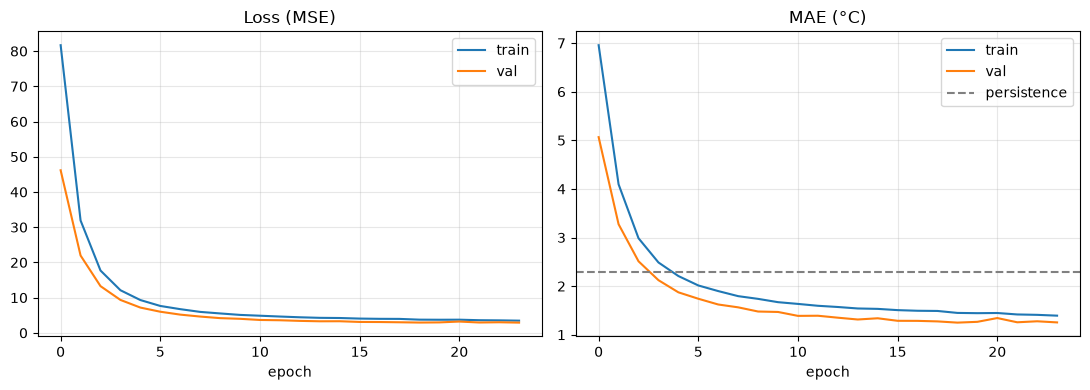

In [8]:
if TRACK == "A":
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(h["loss"], label="train");  ax[0].plot(h["val_loss"], label="val")
    ax[0].set_title("Loss (MSE)"); ax[0].set_xlabel("epoch")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["mae"], label="train");   ax[1].plot(h["val_mae"], label="val")
    ax[1].axhline(baseline_mae, ls="--", c="gray", label="persistence")
    ax[1].set_title("MAE (°C)"); ax[1].set_xlabel("epoch")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()
else:
    print("Skipping Track A")

### A7 — Evaluate on the held-out test split

Targets were never normalised, so the model's output is already in °C and the MAE from
`evaluate` needs no conversion.

In [10]:
if TRACK == "A":
    test_loss, test_mae = model.evaluate(test_ds, verbose=0)

    metric = round(float(test_mae), 3)       # MAE in °C for Moodle a5_metric

    print("persistence baseline MAE : %.3f °C" % baseline_mae)
    print("model test MAE           : %.3f °C" % metric)
    print("improvement              : %.1f %%" % (100 * (1 - metric / baseline_mae)))
    print()
    print("Track A MAE:", metric)
else:
    print("Skipping Track A")

persistence baseline MAE : 2.287 °C
model test MAE           : 1.335 °C
improvement              : 41.6 %

Track A MAE: 1.335


### A8 — Where the error sits, and what a forecast looks like

  t+1h  MAE 0.924 °C
  t+2h  MAE 1.052 °C
  t+3h  MAE 1.194 °C
  t+4h  MAE 1.349 °C
  t+5h  MAE 1.495 °C
  t+6h  MAE 1.608 °C
  t+7h  MAE 1.726 °C


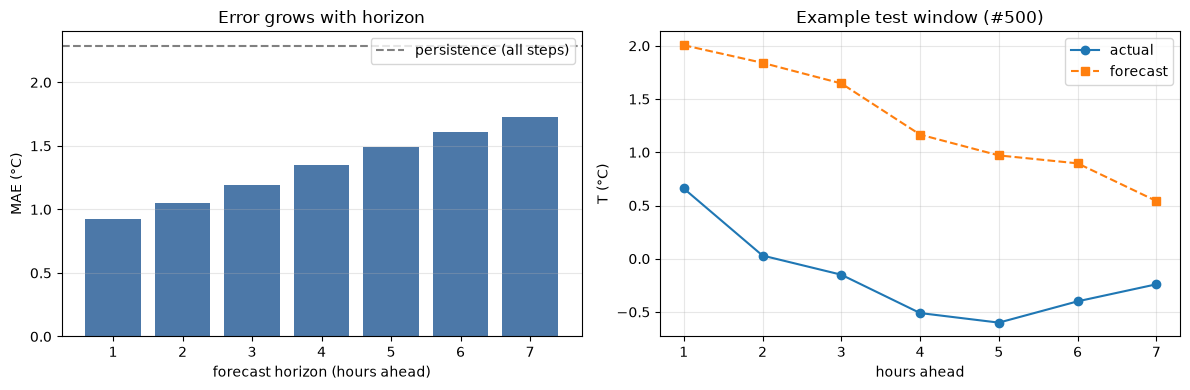

In [11]:
if TRACK == "A":
    y_true = np.concatenate([y.numpy() for _, y in test_ds])
    y_pred = model.predict(test_ds, verbose=0)

    per_step = np.abs(y_pred - y_true).mean(axis=0)
    for k, v in enumerate(per_step, start=1):
        print("  t+%dh  MAE %.3f °C" % (k, v))

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].bar(range(1, HORIZON + 1), per_step, color="#4C78A8")
    ax[0].axhline(baseline_mae, ls="--", c="gray", label="persistence (all steps)")
    ax[0].set_xlabel("forecast horizon (hours ahead)"); ax[0].set_ylabel("MAE (°C)")
    ax[0].set_title("Error grows with horizon")
    ax[0].legend(); ax[0].grid(alpha=.3, axis="y")

    i = 500
    ax[1].plot(range(1, HORIZON + 1), y_true[i], "o-", label="actual")
    ax[1].plot(range(1, HORIZON + 1), y_pred[i], "s--", label="forecast")
    ax[1].set_xlabel("hours ahead"); ax[1].set_ylabel("T (°C)")
    ax[1].set_title("Example test window (#%d)" % i)
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()
else:
    print("Skipping Track A")

---
# Track B — Text (AG News)

Four-class news topic classification.

You decide: how to load AG News (TFDS or another source), vocabulary / sequence length, Embedding + LSTM / Transformer / other, and the train/val/test protocol.

*Not attempted — Track A was chosen. The cell below is left in place and inert.*

In [12]:
if TRACK == "B":
    # Not attempted — see Track A above.
    metric = None
    print("Track B accuracy % (Moodle a5_metric):", metric)
else:
    print("Skipping Track B")

Skipping Track B


---
## Written responses

### Summary (max 100 words)

The 10-minutely Jena CSV (420,550 rows, 14 channels) is subsampled to hourly, with the two wind
columns' `-9999` sentinels reset to 0, then split chronologically 50/25/25 and z-scored using
**training-only** statistics to avoid leakage. `timeseries_dataset_from_array` cuts 120-hour
lookback windows paired with the next 7 raw-°C temperatures. The model is a direct multi-step
Conv1D→LSTM regressor: two `Conv1D(32,5,relu)` + `MaxPooling1D(2)` layers compress the window
into local weather shapes, an `LSTM(48)` summarises the daily cycle, `Dropout(0.2)` regularises,
and `Dense(7)` emits all seven hours at once, avoiding compounding feedback error.